## Imports

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from mdm2_breaker import (
    GraphSiameseNetwork,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer_v5,
    generate_scaffold_split,
    plot_loss,
    train_model,
    view_protein,
    visualize_scaffold_split,
    load_model_from_checkpoint,
    SmallMoleculeFeaturizer_DeepPurpose,
    plot_predictions
)

ROOT = Path(os.getcwd()).parents[0]



In [2]:
BS = 128
EPOCHS = 50
LR = 0.001

In [ ]:
def get_latest_checkpoint(checkpoint_dir="checkpoints"):
    # 1. Define the path
    p = Path(checkpoint_dir)
    
    # 2. Get all .ckpt files
    files = list(p.glob("*.ckpt"))
    
    # 3. Guard clause: Return None if empty
    if not files:
        return None
        
    # 4. Find the file with the most recent modification time (st_mtime)
    latest_file = max(files, key=lambda f: f.stat().st_mtime)
    
    return str(latest_file)


In [3]:
mol_file = os.path.join(
    "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

BENCHMARK_DATA_PATH = os.path.join('..', 'data', 'MDM2_Breaker', 'processed', 'benchmark_data.csv')

df_mol = pd.read_csv(BENCHMARK_DATA_PATH)

def is_valid_molecule(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

# Drop rows with invalid SMILES
df_mol = df_mol[df_mol['SMILES'].apply(is_valid_molecule)]

def sanitize_and_flatten(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        # CRITICAL FIX: Remove the "Wedge/Dash" bond directions
        # This prevents the 'BEGINDASH' error in DGL-LifeSci
        Chem.RemoveStereochemistry(mol)
        
        # Return the canonical, flattened SMILES
        return Chem.MolToSmiles(mol)
    except:
        return None

# 1. Apply the cleaner
df_mol['SMILES'] = df_mol['SMILES'].apply(sanitize_and_flatten)
# 2. Drop rows that failed (became None)
df_mol = df_mol.dropna(subset=['SMILES']).reset_index(drop=True)

train_indices = df_mol[df_mol['split'] == 'train'].index.tolist()
val_indices = df_mol[df_mol['split'] == 'val'].index.tolist()
test_indices = df_mol[df_mol['split'] == 'test'].index.tolist()

In [4]:
from mdm2_breaker.graph_dta_model import GraphDTAModel
MDM2_SEQUENCE = "SQIPASEQETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDEKQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVVVNQQESSDSGTSVSEN"
SAVE_NAME = "GraphDTA-updated"
# Simple Amino Acid Vocabulary
AA_VOCAB = "ACDEFGHIKLMNPQRSTVWY"  # The 20 standard
char_to_int = {c: i + 1 for i, c in enumerate(AA_VOCAB)}  # Start at 1, 0 is padding


def tokenize_sequence(seq, max_len=1000):
    # Convert chars to ints, ignoring unknown chars
    indices = [char_to_int.get(c, 0) for c in seq]

    # Pad or Truncate
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]

    return torch.tensor(indices, dtype=torch.long)


# Usage
mdm2_tensor = tokenize_sequence(MDM2_SEQUENCE).unsqueeze(0)  # Add batch dim

model_gdta, train_loader_gdta, val_loader_gdta, test_loader_gdta = train_model(
    model=GraphDTAModel(
        molecule_in_channels = 74
        ),
    mol_class=SmallMoleculeFeaturizer_DeepPurpose,
    protein_data=mdm2_tensor,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name=SAVE_NAME,
    train=True,
    mol_file=mol_file,
    batch_size=BS,
)

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[e

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GraphDTAModel │  2.3 M │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


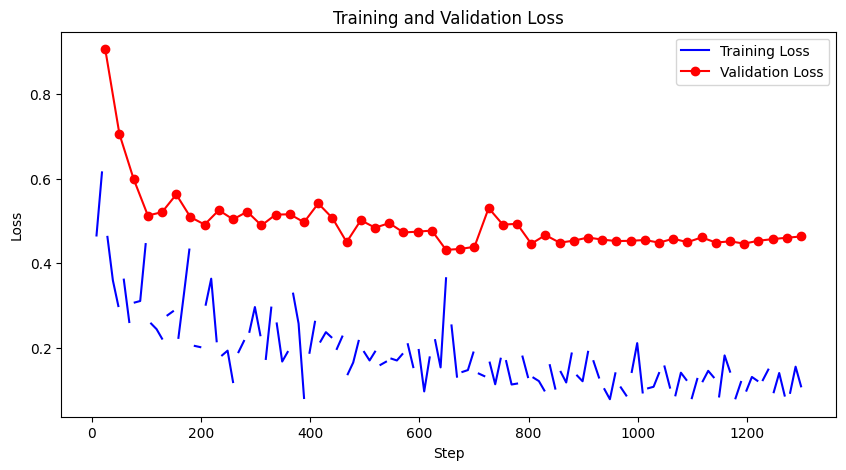

version_41


In [ ]:
latest_loss_curve_idx = max([int(folder.split("_")[-1]) for folder in os.listdir("lightning_logs") if folder.startswith("version_")])
latest_loss_curve = f"version_{latest_loss_curve_idx}"

plot_loss(os.path.join("lightning_logs", latest_loss_curve, "metrics.csv"))
print(f"latest_loss_curve: {latest_loss_curve}")

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)



Total Trainable Parameters: 2,278,402


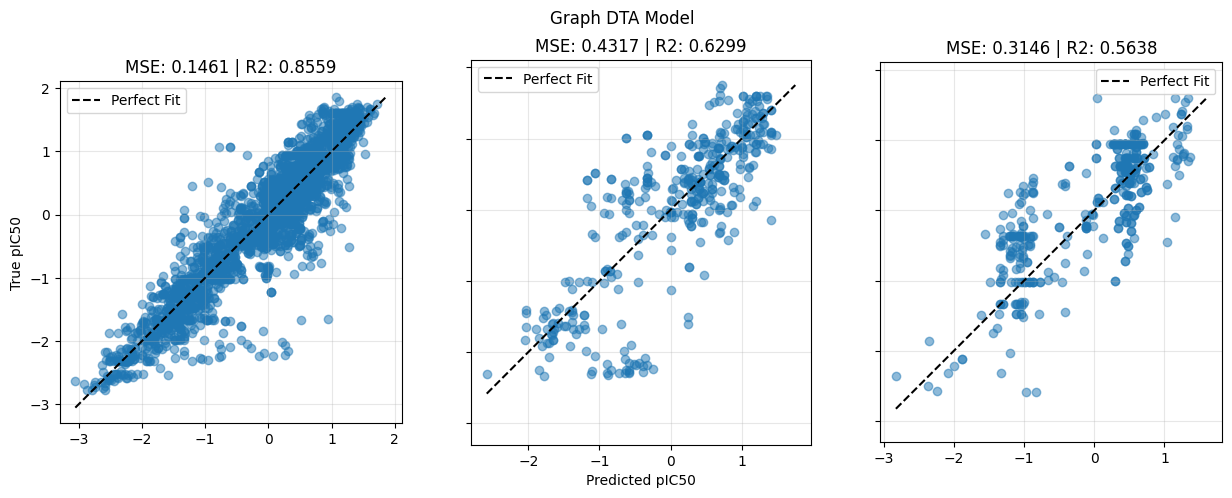

In [ ]:
latest_ckpt = get_latest_checkpoint()
print(f"Loading latest model from: {latest_ckpt}")

# 1. Load the raw checkpoint
checkpoint = torch.load(latest_ckpt)
state_dict = checkpoint["state_dict"]

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model = GraphDTAModel(
    molecule_in_channels = 74
    )

# 4. Load the cleaned weights
model.load_state_dict(new_state_dict)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

model.eval()

plot_predictions(
    model,
    (train_loader_gdta, val_loader_gdta, test_loader_gdta),
    mdm2_tensor,
    "Graph DTA Model",
)

Text(0.5, 1.0, 'Graph DTA (GCN) Predicted vs True pIC50\nR2: 0.4792, MSE: 0.8160')

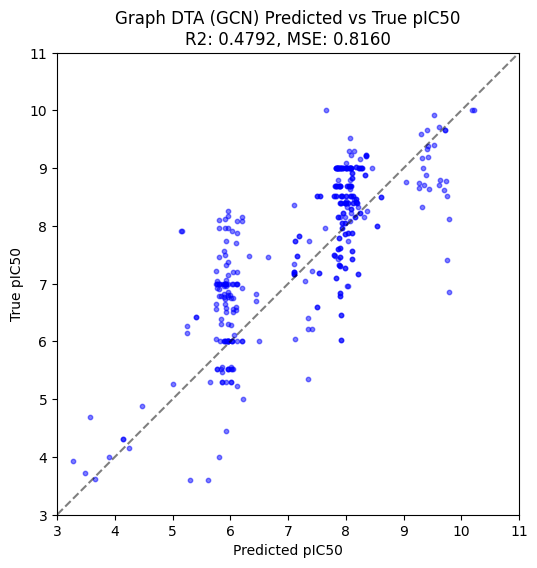

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(os.path.join('..','data', 'MDM2_Breaker', 'processed', 'graphdta_benchmark_results_gin_attr_masking.csv'))
df

mse = mean_squared_error(df["pIC50_pred"], df["pIC50"])
r2 = r2_score(df["pIC50_pred"], df["pIC50"])
_, ax = plt.subplots(1, 1, figsize=(6, 6))
df.plot(
    x = "pIC50_pred",
    y = "pIC50",
    kind = "scatter",
    alpha = 0.5,
    color = "blue",
    s = 10,
    ax = ax,
)
plt.xlim(3, 11)
plt.ylim(3, 11)
ax.set_aspect("equal", "box")
plt.plot([0, 14], [0, 14], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Graph DTA (GCN) Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")


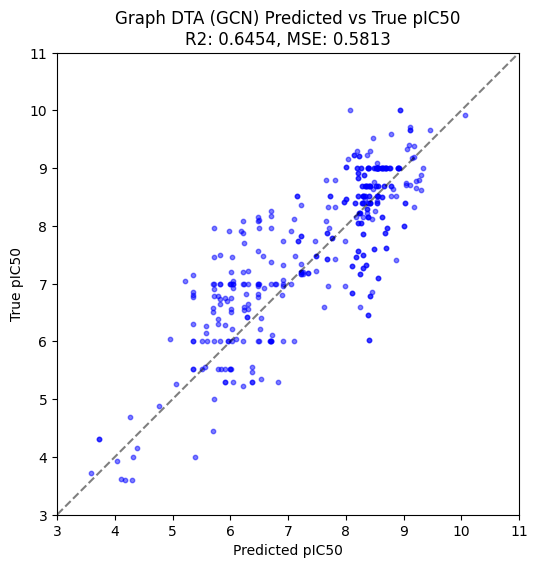

In [14]:
df_gdta = pd.read_csv(
    os.path.join(
        ROOT, "data", "MDM2_Breaker", "processed", "graphdta_benchmark_results.csv"
    )
)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_gdta.plot(
    x="pIC50_pred", y="pIC50", kind="scatter", alpha=0.5, color="blue", s=10, ax=ax
)
r2 = r2_score(df_gdta["pIC50_pred"], df_gdta["pIC50"])
mse = mean_squared_error(df_gdta["pIC50_pred"], df_gdta["pIC50"])
plt.xlim(3, 11)
plt.ylim(3, 11)
ax.set_aspect("equal", "box")
plt.plot([0, 14], [0, 14], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Graph DTA (GCN) Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")
plt.show()